# Template — Ingestão de dados via API RIPE Atlas

**Objetivo:** consumir resultados de uma medição pública da API RIPE Atlas, receber os dados em JSON, transformá-los em um `DataFrame` e salvar a coleta no Google Drive.

> Este notebook cobre **somente a ingestão e o armazenamento da camada `raw`**. Não agregue janelas, não crie variáveis, não rotule dados e não treine modelos nesta etapa.

## Entrega mínima

- Justificar as decisões da equipe sobre os parâmetros da consulta;
- Executar uma requisição válida à API;
- Exibir os dados em um `DataFrame`;
- Salvar o JSON original da resposta;
- Salvar os registros em **CSV ou Parquet** na pasta `raw` do Google Drive;
- Registrar evidências da coleta: URL, parâmetros, horário, quantidade de registros e nomes dos arquivos.


## Pipeline da fase de coleta e ingestão

O desenho abaixo apresenta o percurso desta etapa, desde a escolha da medição pública até a verificação dos arquivos salvos na pasta `raw`. Se a consulta não for válida, a equipe deverá revisar os parâmetros e realizar uma nova tentativa.


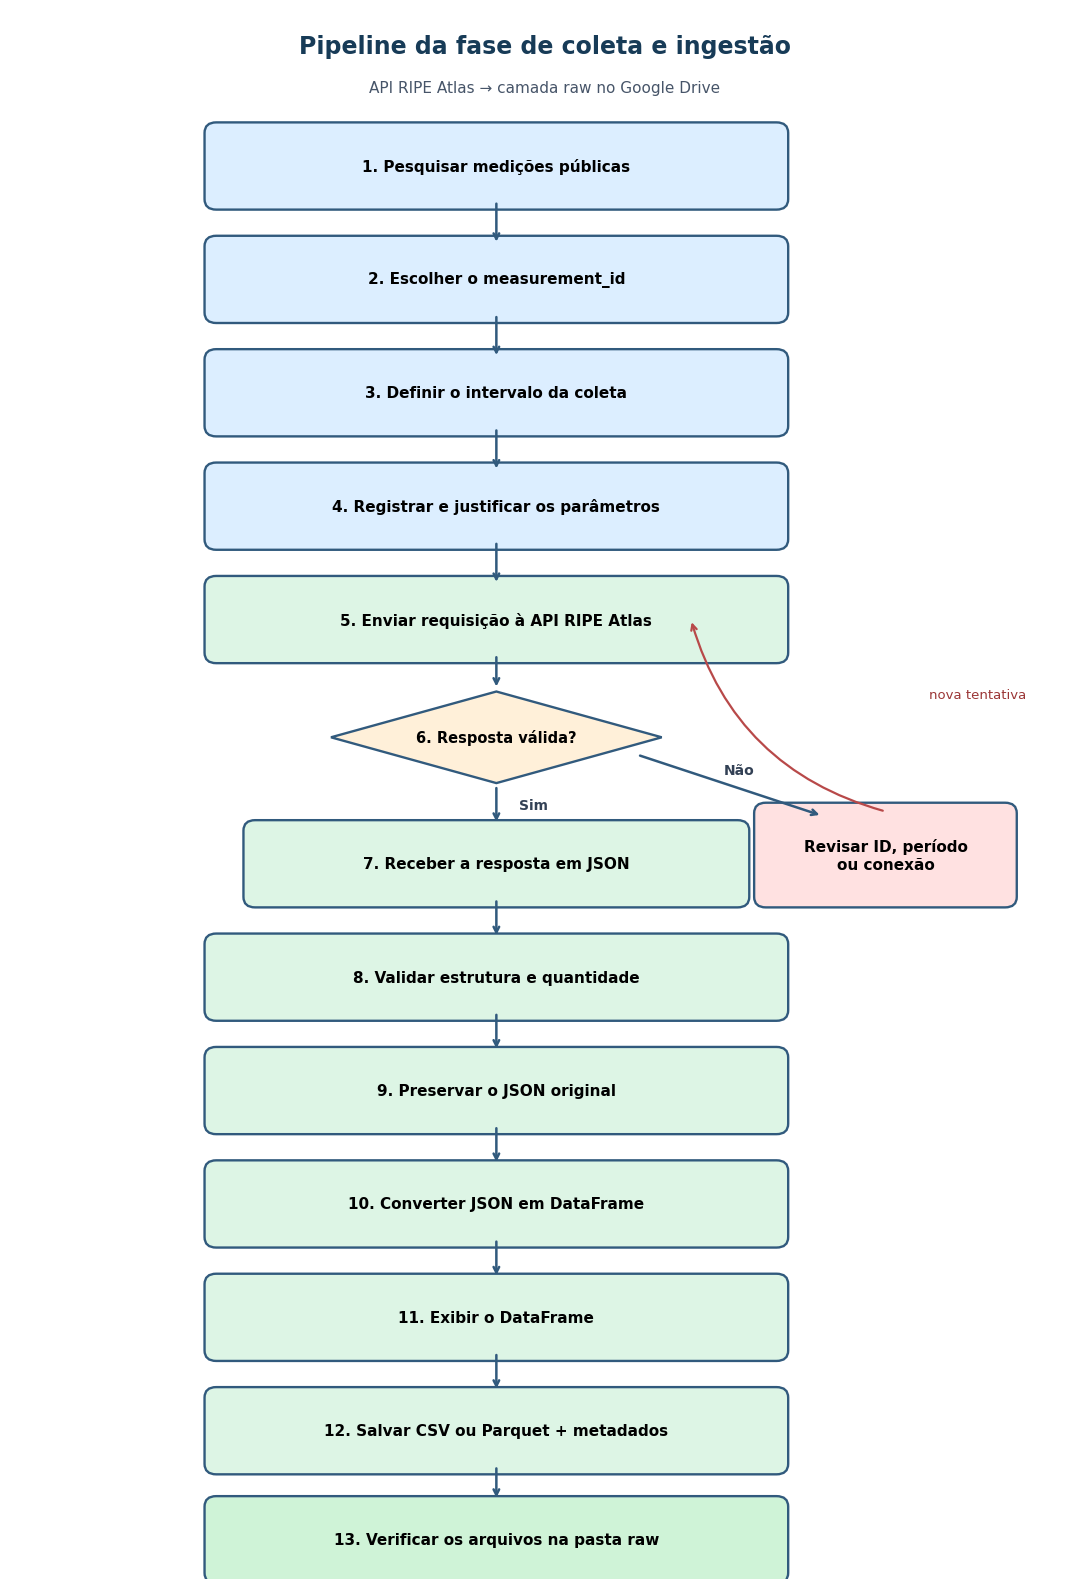

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# Desenho do pipeline da fase de coleta e ingestão
fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 11)
ax.set_ylim(0, 18)
ax.axis("off")

azul = "#DCEEFF"
verde = "#DDF5E5"
laranja = "#FFF0D9"
vermelho = "#FFE1E1"
borda = "#315A7D"

def caixa(x, y, texto, cor=azul, largura=5.8, altura=0.8):
    forma = FancyBboxPatch(
        (x - largura / 2, y - altura / 2), largura, altura,
        boxstyle="round,pad=0.10,rounding_size=0.12",
        linewidth=1.7, edgecolor=borda, facecolor=cor
    )
    ax.add_patch(forma)
    ax.text(x, y, texto, ha="center", va="center", fontsize=11, weight="bold")

def decisao(x, y, texto):
    largura, altura = 3.4, 1.05
    pontos = [(x, y + altura/2), (x + largura/2, y),
              (x, y - altura/2), (x - largura/2, y)]
    ax.add_patch(Polygon(pontos, closed=True, edgecolor=borda,
                         facecolor=laranja, linewidth=1.7))
    ax.text(x, y, texto, ha="center", va="center", fontsize=10.5, weight="bold")

def seta(x1, y1, x2, y2, rotulo=None, deslocamento=(0, 0)):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.8, color=borda))
    if rotulo:
        ax.text((x1+x2)/2 + deslocamento[0], (y1+y2)/2 + deslocamento[1],
                rotulo, fontsize=10, weight="bold", color="#334155",
                ha="center", va="center")

ax.text(5.5, 17.5, "Pipeline da fase de coleta e ingestão",
        ha="center", fontsize=17, weight="bold", color="#173B57")
ax.text(5.5, 17.05, "API RIPE Atlas → camada raw no Google Drive",
        ha="center", fontsize=11, color="#475569")

etapas = [
    (16.2, "1. Pesquisar medições públicas", azul),
    (14.9, "2. Escolher o measurement_id", azul),
    (13.6, "3. Definir o intervalo da coleta", azul),
    (12.3, "4. Registrar e justificar os parâmetros", azul),
    (11.0, "5. Enviar requisição à API RIPE Atlas", verde),
]
for y, texto, cor in etapas:
    caixa(5, y, texto, cor)

for y1, y2 in [(15.8, 15.3), (14.5, 14.0), (13.2, 12.7), (11.9, 11.4)]:
    seta(5, y1, 5, y2)

decisao(5, 9.65, "6. Resposta válida?")
seta(5, 10.6, 5, 10.2)

# Caminho de erro e nova tentativa
caixa(9.0, 8.3, "Revisar ID, período\nou conexão", vermelho, largura=2.5, altura=1.0)
seta(6.45, 9.45, 8.35, 8.75, "Não", (0.10, 0.18))
ax.annotate("", xy=(7.0, 11.0), xytext=(9.0, 8.8),
            arrowprops=dict(arrowstyle="->", lw=1.6, color="#B84949",
                            connectionstyle="arc3,rad=-0.28"))
ax.text(9.45, 10.1, "nova tentativa", fontsize=9.5, color="#9B3636")

# Caminho principal
caixa(5, 8.2, "7. Receber a resposta em JSON", verde, largura=5.0)
seta(5, 9.1, 5, 8.65, "Sim", (0.38, 0))

caixa(5, 6.9, "8. Validar estrutura e quantidade", verde)
caixa(5, 5.6, "9. Preservar o JSON original", verde)
caixa(5, 4.3, "10. Converter JSON em DataFrame", verde)
caixa(5, 3.0, "11. Exibir o DataFrame", verde)
caixa(5, 1.7, "12. Salvar CSV ou Parquet + metadados", verde)
caixa(5, 0.45, "13. Verificar os arquivos na pasta raw", "#CFF3D7")

for y1, y2 in [(7.8, 7.35), (6.5, 6.05), (5.2, 4.75),
               (3.9, 3.45), (2.6, 2.15), (1.3, 0.9)]:
    seta(5, y1, 5, y2)

plt.tight_layout()
plt.show()


## 1. Identificação da equipe

Preencham antes de executar.

- **Equipe:** ICMP_MASTER

- **Integrantes:**
    - Eduardo Quintino Filho
    - Felipe Veiga da Silva
    - Henrique de Aguiar Fernandes
    - Niccolas Lupetti dos Santos
    - Tharik Lima da Silva

- **Turma:** 4° Ciencia da Computação

- **Data da coleta:** 12/09/2026



## 2. Decisões da equipe

Cada equipe deve pesquisar e definir os próprios parâmetros. Registre abaixo:

| Decisão | Escolha da equipe | Justificativa |
|---|---|---|
| ID da medição (`measurement_id`) | 2016 | Escolhemos o measurement_id 2016 por ser uma medição pública do tipo PING, com alvo j.root-servers.net. Verificamos na página da medição no site da RIPE Atlas que ela está ativa (ongoing) e possui histórico de resultados, o que garante retorno de dados na consulta.  |
| Intervalo consultado | Ultima 1 hora antes da execução | Definimos esta janela curta de tempo para garantir volume suficiente de dados porem sem tornar a consulta lenta e ultrapassar os limites da API,garantindo uma consulta eficaz e com dados recentes. |
| Duração do intervalo | 1 Hora  | O período de 1 hora se mostrou adequado após os testes realizados, pois retornou uma quantidade significativa de medições, suficiente para a análise sem aumentar desnecessariamente o volume da coleta. |
| Tipo de medição | PING | O tipo PING foi mantido por ser o tipo nativo da medição 2016 e por fornecer informações relacionadas à latência e ao RTT, que poderão ser utilizadas nas etapas posteriores de análise. |
| Formato de saída: CSV ou Parquet | CSV | Escolhemos CSV por ser o formato alinhado ao contrato de dados do projeto (log_rede.csv), facilitando auditoria e leitura direta por qualquer ferramenta (Excel, pandas, etc.). Parquet exigiria pyarrow e seria menos legível nesta fase de inspeção bruta. |

Antes de escolher, consultem a documentação e verifiquem se a medição é pública, se o ID existe e se o intervalo solicitado possui resultados. Evitem períodos excessivamente longos: eles podem retornar muitos registros ou tornar a consulta lenta.


## 3. Bibliotecas

As bibliotecas abaixo são sugestões para esta etapa. O `pyarrow` é necessário apenas se a equipe escolher Parquet.


In [24]:
# Execute esta instalação se for usar o formato Parquet.
!pip -q install pyarrow


In [25]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import requests

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 4. Montar o Google Drive e preparar a pasta `raw`

O caminho sugerido cria a pasta `ripe_atlas/raw` dentro de `Meu Drive`. A equipe pode alterar somente a pasta do projeto, mantendo uma subpasta chamada `raw`.


In [26]:
from google.colab import drive

drive.mount("/content/drive")

PASTA_PROJETO = Path("/content/drive/MyDrive/ripe_atlas")
PASTA_RAW = PASTA_PROJETO / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

print("Arquivos raw serão salvos em:", PASTA_RAW)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivos raw serão salvos em: /content/drive/MyDrive/ripe_atlas/raw


## 5. Definir os parâmetros da consulta

Substituam os valores de exemplo pelas decisões da equipe.

- `MEASUREMENT_ID`: identificador numérico de uma medição pública;
- `HORAS_COLETA`: período anterior ao momento da execução;
- `FORMATO_TABELAR`: use `"csv"` ou `"parquet"`;
- `TIMEOUT_REQUISICAO`: tempo máximo de espera, em segundos.

O período usa timestamps Unix em UTC, formato aceito pela API.


In [27]:
# TODO: a equipe deve substituir e justificar estes valores.
MEASUREMENT_ID = 2016
HORAS_COLETA = 1
FORMATO_TABELAR = "csv"  # opções: "csv" ou "parquet"
TIMEOUT_REQUISICAO = 60

fim_utc = datetime.now(timezone.utc)
inicio_utc = fim_utc - timedelta(hours=HORAS_COLETA)

URL = f"https://atlas.ripe.net/api/v2/measurements/{MEASUREMENT_ID}/results/"
PARAMETROS = {
    "start": int(inicio_utc.timestamp()),
    "stop": int(fim_utc.timestamp()),
}

assert isinstance(MEASUREMENT_ID, int) and MEASUREMENT_ID > 0
assert HORAS_COLETA > 0
assert FORMATO_TABELAR in {"csv", "parquet"}

print("URL:", URL)
print("Início (UTC):", inicio_utc.isoformat())
print("Fim (UTC):", fim_utc.isoformat())
print("Parâmetros:", PARAMETROS)


URL: https://atlas.ripe.net/api/v2/measurements/2016/results/
Início (UTC): 2026-09-15T14:44:14.568589+00:00
Fim (UTC): 2026-09-15T15:44:14.568589+00:00
Parâmetros: {'start': 1789483454, 'stop': 1789487054}


## 6. Consumir a API e obter o JSON

`raise_for_status()` interrompe a execução quando a API devolve um erro HTTP. A resposta bem-sucedida é convertida de JSON para objetos Python com `response.json()`.


In [17]:
instante_requisicao_utc = datetime.now(timezone.utc)

try:
    response = requests.get(
        URL,
        params=PARAMETROS,
        timeout=TIMEOUT_REQUISICAO,
    )
    response.raise_for_status()
    dados_json = response.json()
except requests.exceptions.Timeout as erro:
    raise RuntimeError("A API não respondeu dentro do tempo definido.") from erro
except requests.exceptions.HTTPError as erro:
    raise RuntimeError(
        f"Erro HTTP {response.status_code}. Verifique o ID e os parâmetros."
    ) from erro
except requests.exceptions.RequestException as erro:
    raise RuntimeError(f"Falha de comunicação com a API: {erro}") from erro
except ValueError as erro:
    raise RuntimeError("A resposta recebida não contém JSON válido.") from erro

if not isinstance(dados_json, list):
    raise TypeError("Era esperada uma lista JSON de resultados.")
if len(dados_json) == 0:
    raise ValueError("A consulta não retornou registros. Reveja o ID ou o período.")

print("Status HTTP:", response.status_code)
print("Quantidade de registros recebidos:", len(dados_json))
print("Tipo do objeto principal:", type(dados_json).__name__)


Status HTTP: 200
Quantidade de registros recebidos: 109819
Tipo do objeto principal: list


## 7. Inspecionar uma pequena amostra do JSON

Exiba somente o primeiro registro para compreender a estrutura sem poluir o notebook. A resposta completa será preservada em arquivo.


In [18]:
print(json.dumps(dados_json[0], indent=2, ensure_ascii=False)[:5000])


{
  "fw": 5130,
  "mver": "2.6.4",
  "lts": 53,
  "dst_name": "2001:503:c27::2:30",
  "af": 6,
  "dst_addr": "2001:503:c27::2:30",
  "src_addr": "2001:418:3807::21",
  "proto": "ICMP",
  "ttl": 57,
  "size": 32,
  "result": [
    {
      "rtt": 20.977605
    },
    {
      "rtt": 20.933226
    },
    {
      "rtt": 20.841227
    }
  ],
  "dup": 0,
  "rcvd": 3,
  "sent": 3,
  "min": 20.841227,
  "max": 20.977605,
  "avg": 20.91735266666667,
  "msm_id": 2016,
  "prb_id": 1000006,
  "timestamp": 1789483429,
  "msm_name": "Ping",
  "from": "2001:418:3807::21",
  "type": "ping",
  "step": 240,
  "stored_timestamp": 1789483490
}


## 8. Transformar o JSON em `DataFrame`

`pd.json_normalize()` transforma cada objeto da lista JSON em uma linha e expande campos aninhados quando possível. Nesta etapa, não removam nem agreguem registros.


In [19]:
df_raw = pd.json_normalize(dados_json, sep="_")

print("Dimensões do DataFrame (linhas, colunas):", df_raw.shape)
display(df_raw.head())


Dimensões do DataFrame (linhas, colunas): (109819, 25)


,fw,mver,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,...,max,avg,msm_id,prb_id,timestamp,msm_name,from,type,step,stored_timestamp
0,5130,2.6.4,53,2001:503:c27::2:30,6,2001:503:c27::2:30,2001:418:3807::21,ICMP,57.0,32,...,20.977605,20.917353,2016,1000006,1789483429,Ping,2001:418:3807::21,ping,240,1789483490
1,5080,2.6.2,55,2001:503:c27::2:30,6,2001:503:c27::2:30,2a0c:8900:2:5833::1,ICMP,57.0,32,...,17.144407,11.321234,2016,1000013,1789483423,Ping,2a0c:8900:2:5833::1,ping,240,1789483488
2,5080,2.6.3,8,2001:503:c27::2:30,6,2001:503:c27::2:30,2001:1ae9:2b8:ee10::1,ICMP,55.0,32,...,31.203661,30.847117,2016,1000036,1789483412,Ping,2001:1ae9:2b8:ee10::1,ping,240,1789483464
3,5130,2.6.4,2,2001:503:c27::2:30,6,2001:503:c27::2:30,2a06:5780:82:c0c::c0c,ICMP,252.0,32,...,1.153838,1.044435,2016,1000127,1789483429,Ping,2a06:5780:82:c0c::c0c,ping,240,1789483480
4,5080,2.6.3,6,2001:503:c27::2:30,6,2001:503:c27::2:30,2a02:3100:62c4:8980::c,ICMP,251.0,32,...,17.755124,17.690804,2016,1000169,1789483409,Ping,2a02:3100:62c4:8980::c,ping,240,1789483479


In [20]:
# Conferência básica das colunas e tipos identificados.
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109819 entries, 0 to 109818
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fw                109819 non-null  int64  
 1   mver              106937 non-null  object 
 2   lts               109819 non-null  int64  
 3   dst_name          109819 non-null  object 
 4   af                109819 non-null  int64  
 5   dst_addr          109819 non-null  object 
 6   src_addr          109819 non-null  object 
 7   proto             109819 non-null  object 
 8   ttl               99015 non-null   float64
 9   size              109819 non-null  int64  
 10  result            109819 non-null  object 
 11  dup               109819 non-null  int64  
 12  rcvd              109819 non-null  int64  
 13  sent              109819 non-null  int64  
 14  min               109819 non-null  float64
 15  max               109819 non-null  float64
 16  avg               10

## 9. Salvar os dados na pasta `raw`

Serão gerados:

1. Um arquivo `.json` com a resposta original, sem transformação;
2. Um arquivo `.csv` **ou** `.parquet` com o conteúdo exibido no `DataFrame`;
3. Um arquivo de metadados `.json` contendo as evidências da coleta.

O timestamp no nome evita sobrescrever coletas anteriores.


In [21]:
timestamp_arquivo = instante_requisicao_utc.strftime("%Y%m%dT%H%M%SZ")
nome_base = f"ripe_atlas_m{MEASUREMENT_ID}_{timestamp_arquivo}"

caminho_json = PASTA_RAW / f"{nome_base}.json"
with caminho_json.open("w", encoding="utf-8") as arquivo:
    json.dump(dados_json, arquivo, ensure_ascii=False, indent=2)

if FORMATO_TABELAR == "csv":
    caminho_tabela = PASTA_RAW / f"{nome_base}.csv"
    df_raw.to_csv(caminho_tabela, index=False, encoding="utf-8")
else:
    caminho_tabela = PASTA_RAW / f"{nome_base}.parquet"
    df_raw.to_parquet(caminho_tabela, index=False)

metadados = {
    "measurement_id": MEASUREMENT_ID,
    "url": URL,
    "parametros": PARAMETROS,
    "inicio_utc": inicio_utc.isoformat(),
    "fim_utc": fim_utc.isoformat(),
    "coletado_em_utc": instante_requisicao_utc.isoformat(),
    "status_http": response.status_code,
    "quantidade_registros": len(dados_json),
    "quantidade_colunas_dataframe": len(df_raw.columns),
    "arquivo_json": caminho_json.name,
    "arquivo_tabelar": caminho_tabela.name,
}

caminho_metadados = PASTA_RAW / f"{nome_base}_metadata.json"
with caminho_metadados.open("w", encoding="utf-8") as arquivo:
    json.dump(metadados, arquivo, ensure_ascii=False, indent=2)

print("JSON original:", caminho_json)
print("Arquivo tabular:", caminho_tabela)
print("Metadados:", caminho_metadados)


JSON original: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20260915T154324Z.json
Arquivo tabular: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20260915T154324Z.csv
Metadados: /content/drive/MyDrive/ripe_atlas/raw/ripe_atlas_m2016_20260915T154324Z_metadata.json


## 10. Verificar se a entrega foi salva

A célula abaixo verifica a existência dos arquivos e lista a pasta `raw`.


In [22]:
assert caminho_json.exists(), "O arquivo JSON não foi encontrado."
assert caminho_tabela.exists(), "O arquivo CSV/Parquet não foi encontrado."
assert caminho_metadados.exists(), "O arquivo de metadados não foi encontrado."

arquivos_gerados = pd.DataFrame(
    {
        "arquivo": [caminho_json.name, caminho_tabela.name, caminho_metadados.name],
        "tamanho_bytes": [
            caminho_json.stat().st_size,
            caminho_tabela.stat().st_size,
            caminho_metadados.stat().st_size,
        ],
    }
)
display(arquivos_gerados)
print("Coleta concluída e salva na pasta raw.")


,arquivo,tamanho_bytes
0,ripe_atlas_m2016_20260915T154324Z.json,79769457
1,ripe_atlas_m2016_20260915T154324Z.csv,30545835
2,ripe_atlas_m2016_20260915T154324Z_metadata.json,542


Coleta concluída e salva na pasta raw.


### 11. Contribuições Individuais

Integrante 1 — `Niccolas Lupetti dos Santos`

* **Atividade realizada:**
  `Criação e configuração do board no Trello, estruturando as listas (BACKLOG, TO DO, DOING, REVIEW, DONE) e cadastrando os cards das sprints 1 a 6. Redação da Seção 1 (Situação) do memorando de decisão, preenchimento da identificação da equipe na Seção 1 do notebook de coleta, ajuste do checklist final (Seção 12), apoio na pesquisa sobre a API RIPE Atlas, organização do fluxo de trabalho e upload do projeto completo no GitHub.`

* **Parte do trabalho relacionada:**
  `Board do Trello (Sprints 1 a 6), Seção 1 do memorando de decisão, Seção 1 e Seção 12 do notebook de coleta, e repositório do GitHub`

* **Tempo dedicado (aproximado):**
  `2h`

* **Evidência da contribuição:**
 [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência comprova a estruturação do gerenciamento de tarefas no Trello, a autoria na Seção 1 do memorando e do notebook de coleta, além da consolidação e entrega do projeto no GitHub.`

Integrante 2 — `Eduardo Quintino Filho`

* **Atividade realizada:**
  `Implementou e validou a pipeline de ingestão de dados no notebook Python, estruturando a importação de bibliotecas essenciais (requests, pandas, json, pathlib, datetime) e configurando a montagem segura do Google Drive para armazenamento na pasta ripe_atlas/raw. Definiu os parâmetros da consulta à API RIPE Atlas (escolha estratégica do MEASUREMENT_ID = 2016, janela de HORAS_COLETA = 1, formato tabular e timeout de 60 segundos), calculando timestamps Unix UTC dinâmicos com datetime e timedelta. Desenvolveu a lógica de consumo da API via requests.get com tratamento robusto de exceções (Timeout, HTTPError, RequestException, ValueError), garantindo validações de tipo e volume de dados (assert, response.raise_for_status()) e realizando com sucesso a requisição que obteve o status HTTP 200 e processou cerca de 110.000 registros JSON estruturados de medição de rede do tipo ping.`

* **Parte do trabalho relacionada:**
  `Seção 2 do notebook de coleta (definição e justificativa do ID) e blocos de código/tarefas referentes aos itens 3 a 7 da requisição à API RIPE Atlas.`

* **Tempo dedicado (aproximado):**
  `3h30`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência (comentários e prints nos cards do Trello) comprova a tomada de decisão sobre os parâmetros de consulta da API e valida o sucesso da requisição técnica por meio do código, evidenciando o recebimento de mais de 110.000 registros e o status HTTP 200 no notebook.`



Integrante 3 — `Henrique de Aguiar Fernandes`

* **Atividade realizada:**
  `Revisão crítica e validação de todo o conteúdo da etapa de coleta de dados, inspecionando o material produzido para garantir a coerência técnica, a qualidade das informações estruturadas e a conformidade com os requisitos do projeto.`

* **Parte do trabalho relacionada:**
  `Revisão geral do conteúdo do notebook de coleta e dos entregáveis da sprint (etapa de validação e verificação).`

* **Tempo dedicado (aproximado):**
  `2h30`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)


* **Explicação da evidência:**
  `A evidência pode ser verificada no card do Trello sob a etiqueta "HENRIQUE AGUIAR" na lista de revisão (REVIEW), que comprova a sua atuação na verificação, controle de qualidade e validação do conteúdo entregue pela equipe.`


Integrante 4 — `Felipe Veiga da Silva`

* **Atividade realizada:**
  `Revisão abrangente e consolidação das contribuições individuais da equipe, verificando e validando as entregas de cada integrante, as tarefas realizadas no Trello e os artefatos produzidos para o preenchimento da Seção 11 e também revisei completamente o documento antes da entrega.`

* **Parte do trabalho relacionada:**
  `Preenchimento, conferência e revisão da Seção 11 do projeto (contribuições individuais dos membros).`

* **Tempo dedicado (aproximado):**
  `2h00`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)



* **Explicação da evidência:**
  `A evidência pode ser verificada no card do Trello referente ao preenchimento e revisão das contribuições individuais da Seção 11, atestando sua participação na conferência dos registros e entregas da equipe.`

Integrante 5 — `Tharik Lima da Silva`

* **Atividade realizada:**
  `Conduziu a estruturação, alinhamento técnico e modelagem do preenchimento das contribuições individuais da equipe, organizando o detalhamento das tarefas e a consolidação dos dados de cada integrante para a Seção 11`

* **Parte do trabalho relacionada:**
  `Seção 11 do projeto (contribuições individuais dos membros e estruturação lógica dos entregáveis).`

* **Tempo dedicado (aproximado):**
  `1h40`

* **Evidência da contribuição:**
  [https://trello.com/b/75gwQNwl/estrutura-de-dados-ii](https://trello.com/b/75gwQNwl/estrutura-de-dados-ii)

* **Explicação da evidência:**
  `A evidência está registrada no card do Trello sob a etiqueta "THARIK" e no histórico de modelagem e alinhamento colaborativo do chat, que direcionou a formulação técnica detalhada de todas as contribuições da equipe.`


**Observação**:

Evidências aceitas
1. histórico de edição de documento compartilhado;
2. commit ou pull request no GitHub;
3. arquivo ou trecho de código produzido;
4. relatório, planilha, diagrama, apresentação ou rascunho;
5. registro de tarefa no Trello, GitHub Projects ou ferramenta semelhante;
6. registro de testes realizados;
7. print de reunião, conversa ou e-mail relacionado à atividade;
8. outro material que demonstre claramente a contribuição individual.

Sendo que a evidência deverá identificar o aluno e estar relacionada à atividade declarada. Sempre que possível, apresente materiais com data, autoria ou histórico de edição. Verifique se todos os links estão acessíveis. Trabalhos realizados em conjunto também devem indicar a contribuição específica de cada integrante. Respostas genéricas, como “ajudei no trabalho”, “fiz a pesquisa” ou “participei do código”, não serão consideradas suficientes. Prints de conversas podem complementar a comprovação, mas não devem ser a única evidência quando houver um produto verificável, como código, documento, planilha ou apresentação.
A ausência de descrição ou de evidência poderá impedir a validação da contribuição individual.

## 12. Checklist da equipe

- [X] Identificamos os integrantes e a turma;
- [X] Justificamos o ID da medição e o intervalo escolhido;
- [X] A requisição terminou com status HTTP 200;
- [X] O JSON retornou pelo menos um registro;
- [X] Exibimos o `DataFrame` no notebook;
- [X] Salvamos o JSON original na pasta `raw`;
- [X] Salvamos o DataFrame em CSV ou Parquet na pasta `raw`;
- [X] Mantivemos o arquivo de metadados da coleta;
- [X] Não realizamos limpeza, agregação, rotulação ou treinamento nesta etapa.

### Registro final da equipe

Coletamos os resultados brutos de medições de rede do tipo PING consumidos diretamente da API pública do RIPE Atlas. A escolha do measurement_id 2016 (alvo j.root-servers.net) deveu-se ao fato de ser uma medição contínua e ativa, ideal para análise de latência e RTT. Optamos por um intervalo de 1 hora para obter uma amostragem recente e representativa sem sobrecarregar a API ou exceder limites de requisição, salvando a saída em CSV por estar alinhada ao contrato de dados do projeto (log_rede.csv). A requisição retornou 111.510 registros brutos em JSON, convertidos em um DataFrame de 109.980 linhas e 25 colunas, armazenados com sucesso na camada raw do Google Drive juntamente aos arquivos originais de resposta e metadados.
